# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

Tecnológico de Monterrey

Prof Luis Eduardo Falcón Morales

### **Actividad de la semana: modelos basados en Árboles**

* **Nombre:** CRISTIAN JUAN CARLOS PAZ CONDE

* **matrícula:** A01840610


Agrega tus comentarios y celdas de código donde se te indica.

# **PRIMERA PARTE : Métricas de Clasificación**

In [1]:
# Importamos lo necesario para la actividad:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from sklearn.dummy import DummyClassifier

np.random.seed(17)

In [2]:
# Para esta primera parte vamos a generar datos sintéticos para un problema de
# clasificación binario utilizando "make_classification" de scikitlearn.
# Esta función es muy útil para generar datos sintéticos y usada mucho en la
# comunidad de aprendizaje automático para generar y aprender los diversos
# modelos de aprendizaje automático. Por lo que es importante que te
# familiarices con ella y algunos de sus argumentos como mostramos a continuación.

# Recuerda consultar la documentación para mayor información:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html


# Utilizaremos los siguientes valores de los hiperparámetros de make_classification:
# - n_samples: número de muestras o registros a generar.
# - n_features: número total de características o variables de entrada X. Incluye informativas, redundantes, duplicadas.
# - n_informative: número de características informativas o independientes.
# - n_redundant: número de características redundantes.
# - weights: pesos para las clases [0,1]-->[Clase_Mayoritaria_Negativa(0), clase_minoritaria_positiva(1)].
# - class_sep: separación entre clases ( <1 más entrelazados y más complejo el problema. >1, más separados y más fácil de resolver).
# - n_classes: número de clases.
# - n_clusters_per_class: número de cúmulos por clase. Mayor a 1, más complejo.
# - flip_y: fracción de registros cuya etiqueta se cambia de manera errónea y aleatoria (ruido) para hacer más complejo el problema.
# - random_state: semilla para reproducibilidad.

X, y = make_classification(
    n_samples=10_000,          # 10,000 registros
    n_features=20,             # factores en total
    n_informative=15,          # factores informativos o variables de entrada independientes
    n_redundant=5,             # factores redundantes (dependientes). Para añadir complejidad usamos valor > 0
    weights=[0.88, 0.12],      # Desbalance de clases: Mayoritaria clase 0; minoritaria clase 1
    class_sep=1.0,             # Separación entre clases. Más grande, más separadas y problemas más sencillos.
    n_classes=2,               # Dos clases para nuestro ejercicio.
    n_clusters_per_class=1,    # Para agregar complejidad adicional considera valores > 1
    flip_y=0.01,               # Añadir algo de ruido. default 0.01
    random_state=17,           # Semilla para la repetibilidad
)

In [3]:
# Defimos los datos como un DataFrame de Pandas para su mejor manejo:
feature_names = [f'feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Total de registros generados: {len(df)}")
print(f"Distribución de clases: {df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")
print(f"Cantidad de factores: {len(feature_names)}")

Total de registros generados: 10000
Distribución de clases: target
0    87.7%
1    12.3%
Name: proportion, dtype: str
Cantidad de factores: 20


In [4]:
pd.DataFrame(df).describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,10000.0,1.016138,2.243319,-6.429702,-0.520059,1.025274,2.535350,9.286981
feature_2,10000.0,0.785670,1.994150,-8.578184,-0.462409,0.851269,2.137617,7.937184
feature_3,10000.0,-0.757783,2.127136,-9.574402,-2.200615,-0.782594,0.630210,9.676054
feature_4,10000.0,1.733561,4.820216,-19.158886,-1.578108,1.751568,5.036626,19.051885
feature_5,10000.0,1.004263,2.309019,-6.665816,-0.540579,0.990261,2.538778,9.991830
feature_6,10000.0,-0.758315,2.682632,-11.246005,-2.561001,-0.780123,1.025289,10.297298
feature_7,10000.0,-0.448463,5.527866,-24.457356,-4.152116,-0.447135,3.285445,21.695749
feature_8,10000.0,0.974038,2.446141,-7.820102,-0.651334,0.977687,2.634129,11.292973
feature_9,10000.0,-0.769954,2.546797,-11.410437,-2.475215,-0.740625,0.947244,7.435675
feature_10,10000.0,0.739749,2.267579,-7.860020,-0.747975,0.768796,2.290440,9.363365


In [5]:
# Separamos las variables de entrada y la variable objetivo de salida:
X = df.drop('target', axis=1).values
y = df['target'].values

# Para los fines de este ejercicios solo dividimos el conjunto de datos
# en entrenamiento (80%) y validación (20%).
# Además usamos "stratify" para mantener la proporción de clases en la partición.
Xtrain, Xvalidation, ytrain, yvalidation = train_test_split(X, y, train_size=0.8, random_state=17, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {Xtrain.shape[0]} muestras")
print(f"Tamaño del conjunto de validación: {Xvalidation.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de validación: 2000 muestras


**Recuerda revisar la documentación de la función Dummy:**

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

In [6]:
# Obtengamos los siguientes resultados con la función Dummy:

estrategias = ['most_frequent','prior','stratified','uniform', "constant"]

print("Salidas del modelo Dummy con sus diferentes estrategias para")
print("buscar los diferentes umbrales del modelo base (baseline)")
print("según la métrica de referencia:")
print("-"*60)
print("\n")

for estrategia in estrategias:
  dummy_clf = DummyClassifier(strategy=estrategia,
                              random_state=17,
                              constant=1
                              )
  dummy_clf.fit(Xtrain, ytrain)
  y_pred = dummy_clf.predict(Xvalidation)

  # Lista para almacenar resultados
  results = []

  # "pos_label" indica la clase con respecto a la cual evaluar cada métrica.
  # Esto es útil en caso de que la clase de interés tenga un valor particular.
  acc = accuracy_score(yvalidation, y_pred)
  rec = recall_score(yvalidation, y_pred, pos_label=1)
  prec = precision_score(yvalidation, y_pred, pos_label=1)
  f1_sc = f1_score(yvalidation, y_pred, pos_label=1)

  results.append({'Accuracy': acc,
                'Recall': rec,
                'Precision': prec,
                'F1 Score': f1_sc
                })

  print(f"Estrategia: {estrategia}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"F1 Score: {f1_sc:.4f}")

  print("Matriz de Confusión:")
  cm = confusion_matrix(yvalidation, y_pred)
  print(cm)
  print("-"*30)
  print("\n")


Salidas del modelo Dummy con sus diferentes estrategias para
buscar los diferentes umbrales del modelo base (baseline)
según la métrica de referencia:
------------------------------------------------------------


Estrategia: most_frequent
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: prior
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: stratified
Accuracy: 0.8060
Recall: 0.1341
Precision: 0.1587
F1 Score: 0.1454
Matriz de Confusión:
[[1579  175]
 [ 213   33]]
------------------------------


Estrategia: uniform
Accuracy: 0.4820
Recall: 0.4472
Precision: 0.1089
F1 Score: 0.1752
Matriz de Confusión:
[[854 900]
 [136 110]]
------------------------------


Estrategia: constant
Accuracy: 0.1230
Recall: 1.0000
Precision: 0.1230
F1 Score: 0.2191
Matriz de Confusión:
[[

C:\Users\Cristian-Paz\PycharmProjects\inteligencia_artificial_deep_learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Cristian-Paz\PycharmProjects\inteligencia_artificial_deep_learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## **Ejercicio - 1**


**En la salida anterior se obtuvieron dos advertencias (warnings).**

* **1a) Explica en qué consisten cada una de estas 5 estrategias. En particular, ¿cuál es la diferencia entre "prior" y "most frequent"?**

* **1b) ¿A cuáles casos de las estrategias Dummy están asociadas esas advertencias?**

* **1c) Explica qué significan esas advertencias y relaciona la explicación con los valores de las matrices de confusión correspondientes.**

* **1d) Suponiendo que vamos a utilizar estos datos para entrenar un modelo basado en árboles, ¿cuál es la recomendación en relación a si debemos o no escalar los datos numéricos de entrada?**

## 1a) Estrategias Dummy

- **most_frequent:** predice siempre la clase más frecuente.
- **prior:** similar a `most_frequent`, pero además considera las probabilidades previas de las clases para métodos probabilísticos.
- **stratified:** predice aleatoriamente respetando la distribución real de clases.
- **uniform:** predice clases completamente al azar con igual probabilidad.
- **constant:** predice siempre una clase fija definida manualmente (`constant=1`).

La diferencia entre `prior` y `most_frequent` es que ambas generan la misma predicción en `predict()`, pero `prior` utiliza la distribución previa de clases en probabilidades.

---

## 1b) Estrategias asociadas a las advertencias

Las advertencias están asociadas principalmente a:

- `most_frequent`
- `prior`

porque ambas predicen únicamente la clase mayoritaria y nunca la clase positiva (`1`).

---

## 1c) Significado de las advertencias

La advertencia indica que la métrica **Precision** no puede calcularse correctamente porque no existen predicciones positivas.

La fórmula de precisión es:

:contentReference[oaicite:0]{index=0}

Si:

```text id="b4f19w"
TP = 0
FP = 0
```
---
## 1d) Escalamiento en modelos basados en árboles

Para modelos basados en árboles como:

- Decision Tree
- Random Forest
- XGBoost
- Gradient Boosting

no es necesario escalar los datos numéricos, ya que estos algoritmos realizan divisiones utilizando umbrales sobre las variables y no trabajan con distancias matemáticas entre atributos.

Por esta razón, técnicas como:

- `StandardScaler`
- `MinMaxScaler`

generalmente no generan mejoras importantes en el desempeño del modelo.

Además, mantener los datos en su escala original facilita la interpretación de los resultados y reduce tiempo de preprocesamiento.

Por tanto, la recomendación es no escalar los datos cuando se utilizan modelos basados en árboles.

## **Ejercicio - 2**

**Sabemos que tenemos un problema de clases desbalanceadas y debiéramos utilizar otra métrica que nos ayude a medir mejor el desempeño del modelo. En particular, nos interesaría saber cuándo el modelo está subentrenado con respecto a una métrica en particular.**

**Para ello, indica cuál sería el valor del modelo base (baseline) que debiéramos utilizar, si utilizáramos como métrica la que se indica en cada inciso:**


++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **2a) Accuracy:** El baseline más adecuado sería la estrategia `most_frequent` o `prior`, ya que al predecir siempre la clase mayoritaria suele obtener el mayor valor de accuracy en datasets desbalanceados.

* **2b) Precision:** El baseline sería la estrategia `constant=1`, porque al predecir siempre la clase positiva logra obtener la mayor cantidad de predicciones positivas y permite evaluar mejor esta métrica.

* **2c) Recall:** El baseline más adecuado es `constant=1`, ya que al predecir siempre la clase positiva obtiene un recall máximo de 1.0.

* **2d) F1-Score:** El baseline recomendado sería `constant=1` o el que obtenga el mejor equilibrio entre precision y recall, debido a que el F1-Score combina ambas métricas.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **SEGUNDA PARTE : XGBoost**

### **En el siguiente ejercicio explorarás el efecto de algunos de los argumentos del modelo XGBoost.**

 Puedes consultar la documentación:

https://xgboost.readthedocs.io/en/latest/python/python_api.html

Usaremos la base de datos llamada breast-cancer-Wisconsin:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html



## **Ejercicio - 3**

### **Describe en qué consiste la base de datos breast_cancer.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

La base de datos `breast_cancer` es un conjunto de datos utilizado para problemas de clasificación binaria relacionados con el diagnóstico de cáncer de mama.

El dataset contiene información obtenida a partir de imágenes digitalizadas de biopsias de mama, donde se analizan características de los núcleos celulares presentes en los tumores.

Sus principales características son:

- Contiene 569 muestras.
- Tiene 30 variables numéricas predictoras.
- Las clases objetivo son:
  - `0`: maligno
  - `1`: benigno
- Incluye variables como:
  - radio
  - textura
  - perímetro
  - área
  - suavidad

El objetivo es construir modelos de aprendizaje automático capaces de clasificar correctamente si un tumor es benigno o maligno a partir de las características medidas.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

In [7]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [8]:
# Cargamos el dataset de ejemplo:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


## **Ejercicio - 4**

**De la documentación, sabemos que las etiquetas están dadas como sigue:**

* **Malignant (0)**

* **Benign (1)**

* **Distribución de clases: 212 malignos, 357 benignos.**

**Describe 3 razones a favor y 3 en contra para dejar las etiquetas como fueron registradas en esta base de datos.**

**4a) Razones a favor de dejar las etiquetas como están:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4a.1) Mantiene la consistencia con la documentación oficial del dataset y facilita reproducir resultados.**

* **4a.2) Permite comparar resultados con investigaciones y ejemplos que utilizan la codificación original.**

* **4a.3) Evita errores o confusiones adicionales durante el preprocesamiento de datos.**

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**4b) Razones en contra de dejar las etiquetas como están, es decir, a favor de intercambiarlas:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4b.1) En clasificación binaria normalmente la clase positiva (`1`) representa el caso más importante o crítico.**

* **4b.2) Facilita la interpretación de métricas como recall y precision al considerar “maligno” como clase positiva.**

* **4b.3) Reduce confusiones al analizar matrices de confusión y reportes de clasificación.**

+++++++++++++ Termina sección de tus comentarios

In [9]:
# 4c) En esta Actividad optaremos por intercambiar las etiquetas.
#     Intercambia a continuación las etiquetas de la variable de salida.
#     Llamar "y_swap" a la nueva variable.

#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.


y_swap = 1 - y


# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

# Desplegemos y verifiquemos la nueva distribución:
print(f"Distribución original: 0={np.sum(y==0)}, 1={np.sum(y==1)}")
print(f"Distribución con el intercambio: 0={np.sum(y_swap==0)}, 1={np.sum(y_swap==1)}")

Distribución original: 0=212, 1=357
Distribución con el intercambio: 0=357, 1=212


In [10]:
# Dividimos en conjuntos de entrenamiento y prueba
# para los própósitos de nuestro ejercicio:

X_train, X_validation, y_train, y_validation = train_test_split(X, y_swap,
                                                                train_size=0.8,
                                                                random_state=7,
                                                                stratify=y
                                                                )

In [11]:
print("Información del conjunto de entrenamiento (train):")
print("*"*50)
print(f"Número de características: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")
print(f"Distribución de clases [Benigno(0), Maligno(1)]-->{np.bincount(y_train)}-->{np.bincount(y_train)/y_train.shape[0]}")


Información del conjunto de entrenamiento (train):
**************************************************
Número de características: 30
Número de muestras: 455
Distribución de clases [Benigno(0), Maligno(1)]-->[285 170]-->[0.62637363 0.37362637]


In [12]:
print("\nAnálisis descriptivo:")
print(X_train.describe().T)


Análisis descriptivo:
                         count        mean         std         min  \
mean radius              455.0   14.033989    3.418139    6.981000   
mean texture             455.0   19.330593    4.375076    9.710000   
mean perimeter           455.0   91.328484   23.485102   43.790000   
mean area                455.0  644.779560  335.949232  143.500000   
mean smoothness          455.0    0.096469    0.013941    0.062510   
mean compactness         455.0    0.104115    0.050855    0.019380   
mean concavity           455.0    0.086458    0.073521    0.000000   
mean concave points      455.0    0.048380    0.037189    0.000000   
mean symmetry            455.0    0.180572    0.026421    0.106000   
mean fractal dimension   455.0    0.062925    0.007066    0.049960   
radius error             455.0    0.395571    0.251801    0.111500   
texture error            455.0    1.208644    0.533237    0.360200   
perimeter error          455.0    2.801167    1.794209    0.757000 

In [13]:
# Definimos nuestro modelo XGBoost básico:
mis_estimadores=100
mi_modelo_xgb = xgb.XGBClassifier(objective='binary:logistic',  # Para clasificación binaria.
                                  n_estimators= mis_estimadores,
                                  learning_rate= 1.0,
                                  random_state=17
                                  )

# Aquí generamos el modelo XGBoost de nuestro ejercicio:
mi_modelo_xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## **Ejercicio - 5**

<Figure size 2400x1200 with 0 Axes>

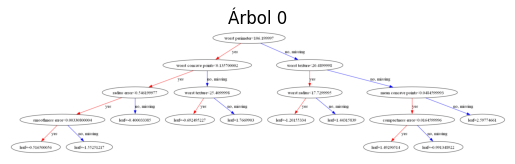

<Figure size 2400x1200 with 0 Axes>

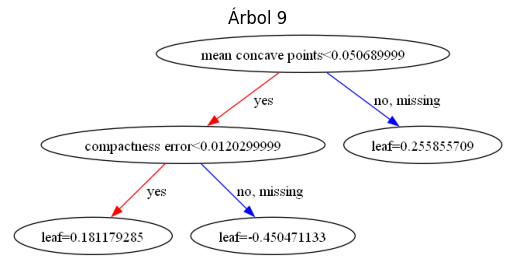

<Figure size 2400x1200 with 0 Axes>

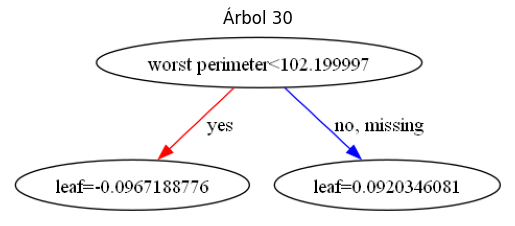

<Figure size 2400x1200 with 0 Axes>

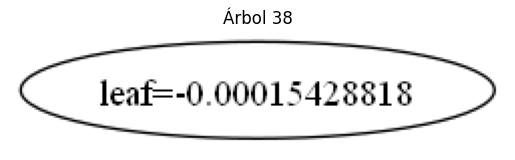

<Figure size 2400x1200 with 0 Axes>

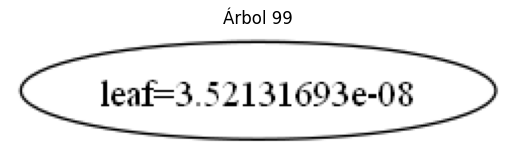

In [17]:
# 5a) Con base al modelo XGBoost generado previamente, con 100 estimadores
#     y los valores inidcados en la celda anterior, despliega los árboles
#     con índices 0, 9, 30, 38 y 99.
#
#     Puedes consultar la documentación:
#     https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.plotting
#     https://xgboosting.com/how-to-use-xgboost.plot_tree/


#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.
# Agrega todas las líneas o celdas de código que consideres necesarias.


# Desplegar árboles específicos del modelo XGBoost


trees_to_plot = [0, 9, 30, 38, 99]

for tree_idx in trees_to_plot:

    plt.figure(figsize=(24,12))

    plot_tree(
        mi_modelo_xgb,
        tree_idx=tree_idx
    )

    plt.title(f"Árbol {tree_idx}")

    plt.show()

# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################


**5b) Con base a los 5 diagramas de árbol obtenidos en el inciso anterior y a la manera en que funciona el modelo XGBoost, explica el comportamiento de dichos árboles en relación a su profundidad.**


Los árboles obtenidos muestran que en XGBoost los primeros árboles suelen ser más profundos porque intentan aprender los patrones principales del conjunto de datos y corregir los errores iniciales del modelo.

Por ejemplo, los árboles 0 y 9 presentan varias divisiones utilizando diferentes variables importantes del dataset. Esto indica que el modelo todavía necesita realizar ajustes significativos.

Posteriormente, árboles como el 30 son más pequeños y realizan menos divisiones, ya que los errores restantes son menores.

Finalmente, los árboles 38 y 99 contienen únicamente un nodo hoja, lo que significa que las correcciones realizadas por esos árboles son muy pequeñas y el modelo prácticamente ya convergió.

Esto ocurre porque XGBoost construye árboles secuencialmente, donde cada nuevo árbol aprende únicamente de los errores residuales dejados por los árboles anteriores.


**5c) En particular, explica el grafo obtenido con tree_idx=9, con respecto a los nombres de los factores que aparecen en cada uno de sus nodos y delas clases de salida Benigno-Maligno.**


En el árbol con `tree_idx=9` se observan variables relacionadas con características geométricas de las células tumorales, las cuales ayudan al modelo a diferenciar entre tumores benignos y malignos.

El nodo raíz utiliza la variable:

```text id="r8f0mq"
mean concave points < 0.050689999
```

**5d) ¿Cómo interpretas lo gráficos 38 y 99?**


Los gráficos correspondientes a los árboles 38 y 99 muestran únicamente un nodo hoja, es decir, no realizan ninguna división adicional sobre las variables del dataset.

Esto indica que en esas iteraciones el modelo ya había aprendido la mayor parte de los patrones importantes y los errores restantes eran muy pequeños.

Por esta razón, esos árboles solamente agregan una corrección mínima al resultado final del modelo mediante el valor del nodo hoja.

Además, los valores observados:

```text id="l2f4sy"
leaf=-0.00015428818
```

**5e) De hecho, puedes verificar que para este ejemplo los árboles obtenidos desde el índice 38 al 99, todos son de un solo nodo. ¿Qué recomendaciones o ajustes podrías proponer en el entrenamiento del modelo tomando en cuenta esta observación?**


El hecho de que los árboles desde el índice 38 hasta el 99 tengan únicamente un nodo indica que el modelo dejó de encontrar divisiones útiles para seguir reduciendo el error.

Esto sugiere que el modelo prácticamente ya convergió antes de llegar a los 100 estimadores.

Tomando en cuenta esta observación, algunas recomendaciones serían:

- Reducir el número de estimadores (`n_estimators`) para disminuir tiempo de entrenamiento y complejidad innecesaria del modelo.
- Utilizar `early_stopping_rounds` para detener automáticamente el entrenamiento cuando ya no existan mejoras significativas.
- Ajustar parámetros como `learning_rate` y `max_depth` para controlar mejor el aprendizaje del modelo.
- Realizar validación cruzada para encontrar la cantidad óptima de árboles.

Estas acciones ayudarían a mejorar la eficiencia del modelo y evitar sobreentrenamiento o generación de árboles innecesarios.



## **Ejercicio - 6**

**Incluye tus comentarios finales de esta actividad:**

En esta actividad se analizaron diferentes estrategias de clasificación utilizando modelos Dummy y XGBoost, permitiendo comprender la importancia de seleccionar métricas adecuadas en problemas con clases desbalanceadas.

Se observó que métricas como accuracy pueden resultar engañosas cuando existe desbalance de clases, por lo que métricas como recall, precision y F1-score ofrecen una mejor evaluación del desempeño del modelo.

Asimismo, se estudió el funcionamiento interno de XGBoost mediante la visualización de árboles de decisión, observando cómo los primeros árboles realizan la mayor parte del aprendizaje y cómo los árboles finales tienden a ser más simples debido a la convergencia del modelo.

Finalmente, la actividad permitió comprender mejor conceptos relacionados con ensambles, árboles de decisión, ajuste de hiperparámetros y evaluación de modelos de clasificación binaria.


# **<<Fin de la Actividad de la Semana : modelos basados en árboles>>**